# Supplementary Figure S2: gsMap Technical Validation
Validation of the gsMap pipeline components: GVAE latent space, gene marker scores, and spatial LDSC p-values.

In [1]:
%matplotlib inline
import omicverse as ov
ov.style(font_path='Arial')

🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc
import os
from scipy.stats import pearsonr

LEGEND_FS = 11; TICK_FS = 12; LABEL_FS = 13; TITLE_FS = 13; TEXT_FS = 12

def save_all_formats(fig, basepath, dpi=300):
    fig.savefig(f"{basepath}.pdf", bbox_inches="tight", dpi=dpi)
    fig.savefig(f"{basepath}.png", bbox_inches="tight", dpi=dpi)
    fig.savefig(f"{basepath}.svg", bbox_inches="tight")

BASE = '../analysis/26_gsmap'
os.makedirs(f'{BASE}/figures', exist_ok=True)

# Available processed samples
available_samples = sorted([d for d in os.listdir(f'{BASE}/models/gsmap_output/')
                            if os.path.isdir(f'{BASE}/models/gsmap_output/{d}')])
print('Available samples:', available_samples)

Available samples: ['Bone_Marrow_CTRL1', 'Bone_Marrow_CTRL2', 'Brain_CTRL1', 'Brain_CTRL2', 'Brown_Fat_CTRL1', 'Brown_Fat_CTRL2', 'Colon_CTRL1', 'Colon_CTRL2', 'Heart_CTRL1', 'Heart_CTRL2', 'Kidney_CTRL1', 'Kidney_CTRL2', 'Liver_CTRL1', 'Liver_CTRL2', 'Lung_CTRL1', 'Lung_CTRL2', 'Lymph_Node_CTRL1', 'Lymph_Node_CTRL2', 'Muscle_CTRL1', 'Muscle_CTRL2', 'Pancreas_CTRL1', 'Pancreas_CTRL2', 'Skin_CTRL1', 'Skin_CTRL2', 'Small_Intestine_CTRL1', 'Small_Intestine_CTRL2', 'Spleen_CTRL1', 'Spleen_CTRL2', 'Stomach_CTRL1', 'Stomach_CTRL2', 'Thymus_CTRL1', 'Thymus_CTRL2']


## Panel A: UMAP of GVAE latent space colored by annotation

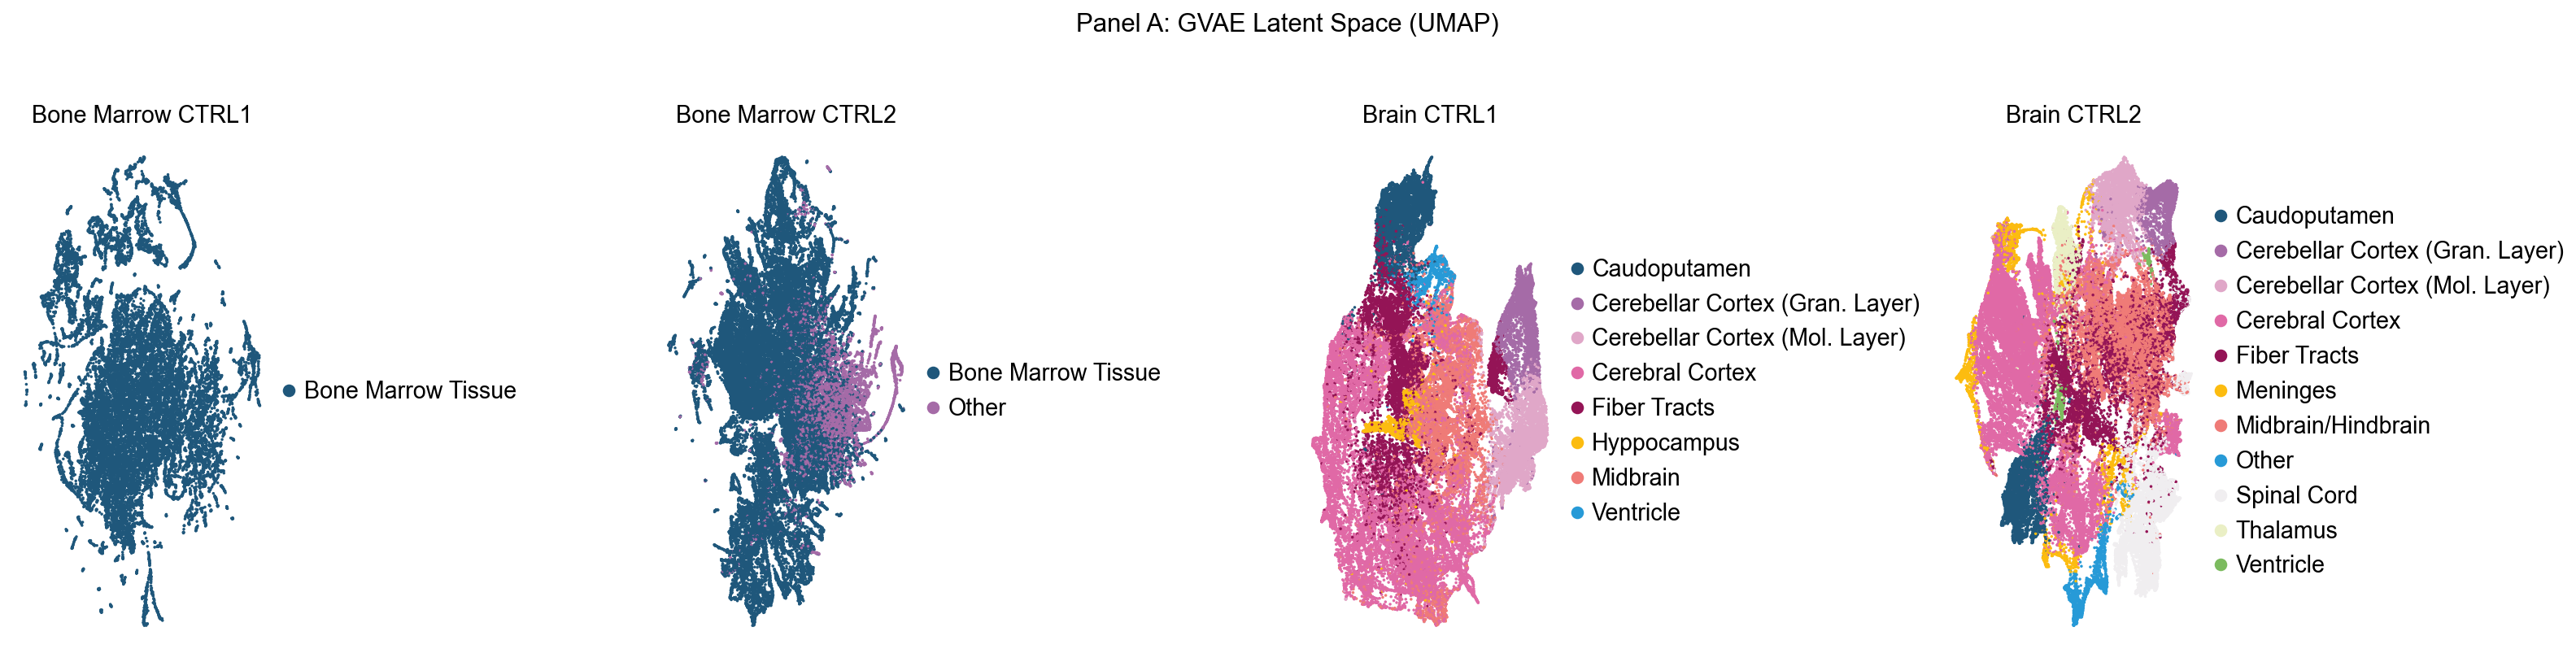

In [3]:
# Load latent h5ad for available samples and compute UMAP on GVAE latent
latent_samples = available_samples[:4]  # up to 4 organs
fig, axes = plt.subplots(1, len(latent_samples), figsize=(5 * len(latent_samples), 5))
if len(latent_samples) == 1:
    axes = [axes]

for ax, sname in zip(axes, latent_samples):
    latent_path = f'{BASE}/models/gsmap_output/{sname}/find_latent_representations/{sname}_add_latent.h5ad'
    adata_lat = ad.read_h5ad(latent_path)
    # Use GVAE latent for UMAP
    sc.pp.neighbors(adata_lat, use_rep='latent_GVAE', n_neighbors=15)
    sc.tl.umap(adata_lat)
    sc.pl.umap(adata_lat, color='annotation', ax=ax, show=False, title=sname.replace('_', ' '),
               legend_loc='right margin', frameon=False, size=10)
    ax.set_title(sname.replace('_', ' '), fontsize=TITLE_FS)
    del adata_lat

fig.suptitle('Panel A: GVAE Latent Space (UMAP)', fontsize=TITLE_FS + 1, y=1.02)
fig.tight_layout()
save_all_formats(fig, f'{BASE}/figures/S02A_gvae_umap')

## Panel B: Distribution of gene marker scores (GSS)

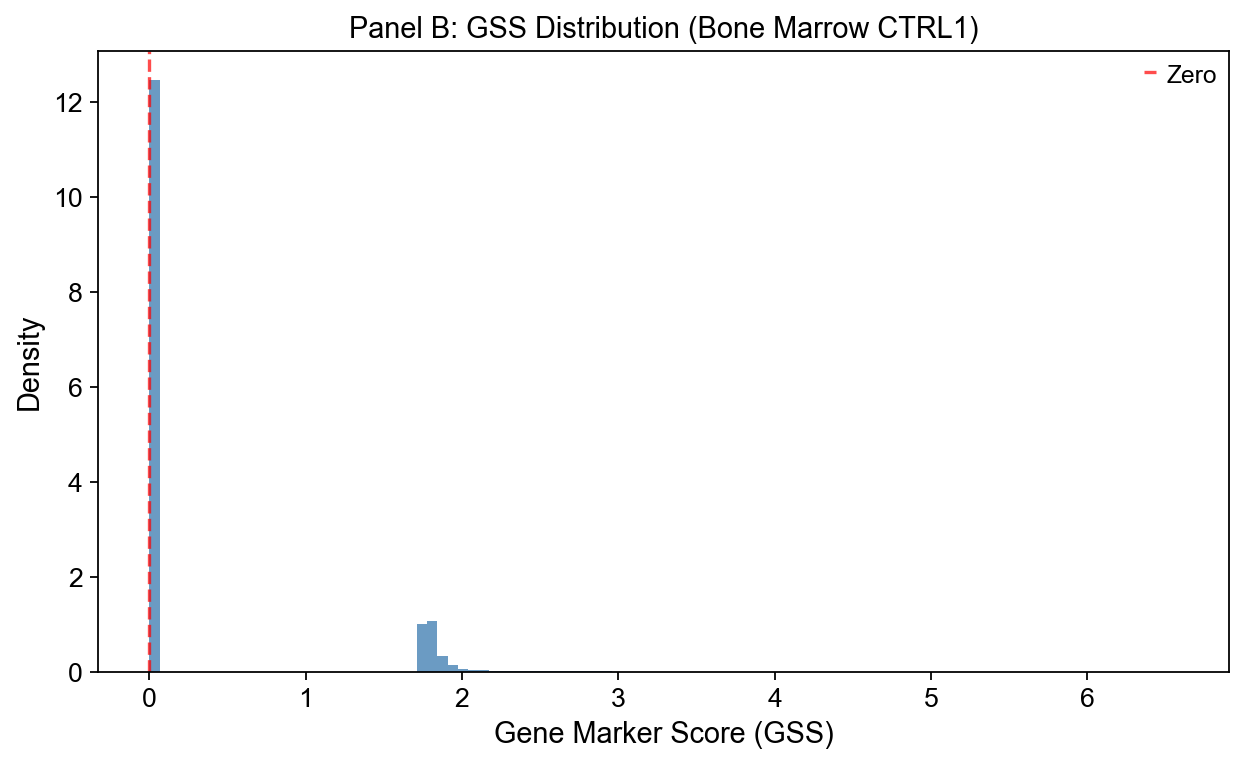

In [4]:
# Use first available sample
rep_sample = available_samples[0]
gms_path = f'{BASE}/models/gsmap_output/{rep_sample}/latent_to_gene/{rep_sample}_gene_marker_score.feather'
gms = pd.read_feather(gms_path)

# GSS values are in columns (spots), rows are genes; flatten all values
gss_values = gms.iloc[:, 1:].values.flatten()  # skip HUMAN_GENE_SYM column
# Sample for performance
rng = np.random.default_rng(42)
gss_sample = rng.choice(gss_values[~np.isnan(gss_values)], size=min(1_000_000, len(gss_values)), replace=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(gss_sample, bins=100, color='steelblue', edgecolor='none', alpha=0.8, density=True)
ax.axvline(0, color='red', linestyle='--', alpha=0.7, label='Zero')
ax.set_xlabel('Gene Marker Score (GSS)', fontsize=LABEL_FS)
ax.set_ylabel('Density', fontsize=LABEL_FS)
ax.set_title(f'Panel B: GSS Distribution ({rep_sample.replace("_", " ")})', fontsize=TITLE_FS)
ax.tick_params(labelsize=TICK_FS)
ax.legend(fontsize=LEGEND_FS)
fig.tight_layout()
save_all_formats(fig, f'{BASE}/figures/S02B_gss_distribution')

## Panel C: QQ plot of spatial LDSC p-values per organ

In [5]:
# Load spot-level p-values from spatial_ldsc output
spot_dfs = []
for sname in available_samples:
    fpath = f'{BASE}/models/gsmap_output/{sname}/spatial_ldsc/{sname}_AD.csv.gz'
    if os.path.exists(fpath):
        df = pd.read_csv(fpath)
        df['sample_name'] = sname
        df['organ'] = sname.rsplit('_', 1)[0].replace('_', ' ')
        spot_dfs.append(df)

spot_all = pd.concat(spot_dfs, ignore_index=True)
print(f'Total spots with p-values: {len(spot_all)}')

Total spots with p-values: 1120354


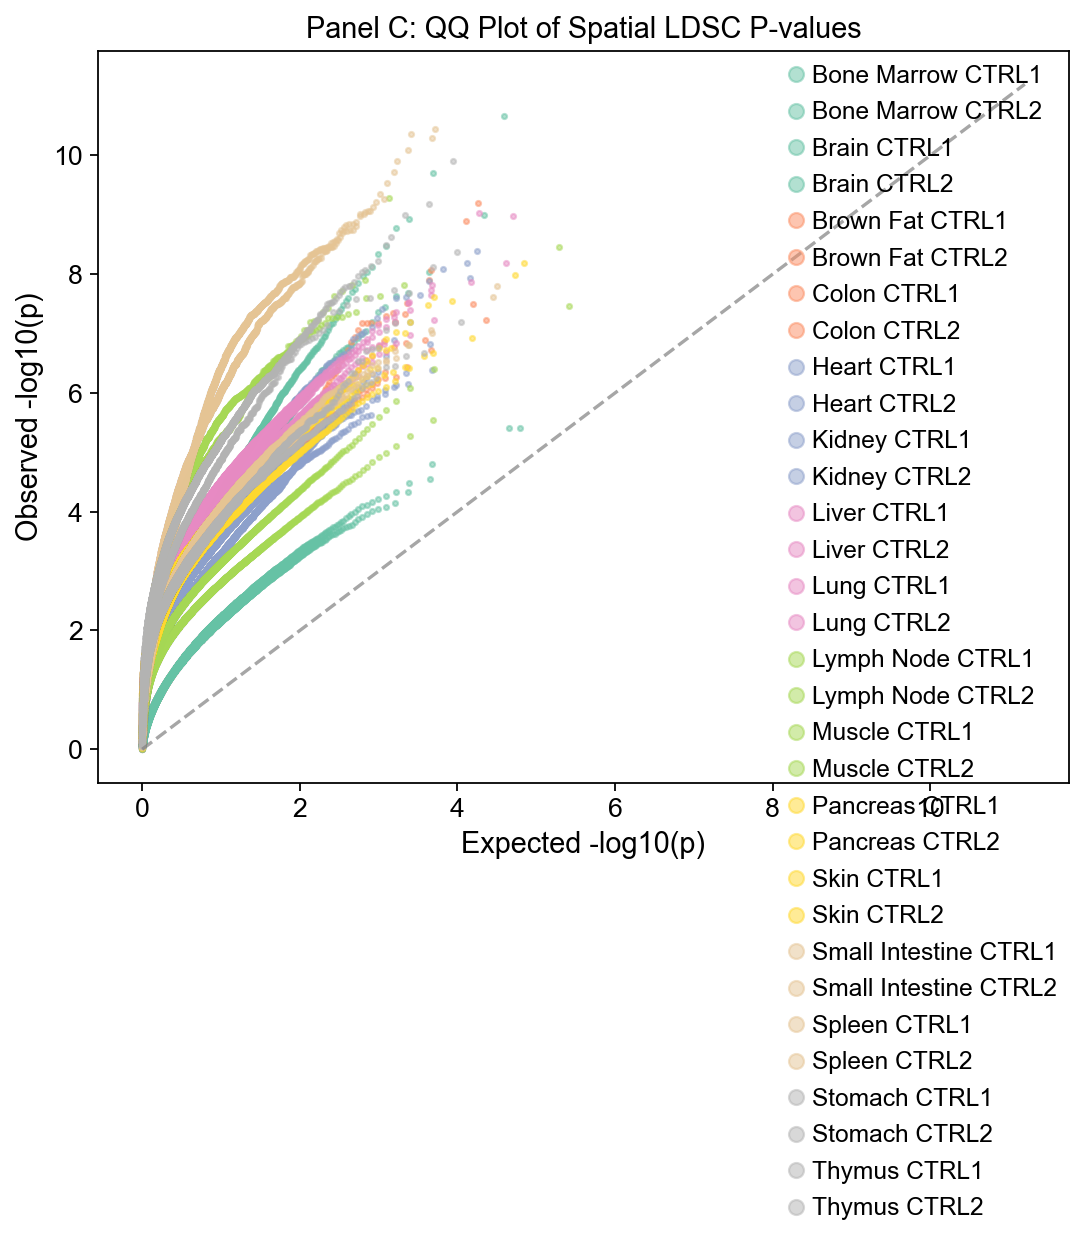

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))

colors = plt.cm.Set2(np.linspace(0, 1, len(available_samples)))

for i, sname in enumerate(available_samples):
    sub = spot_all[spot_all['sample_name'] == sname].copy()
    pvals = sub['p'].dropna().sort_values().values
    n = len(pvals)
    expected = -np.log10(np.arange(1, n + 1) / (n + 1))
    observed = -np.log10(pvals)
    # Sort for QQ
    expected_sorted = np.sort(expected)[::-1]
    observed_sorted = np.sort(observed)[::-1]
    # Subsample for plotting
    idx = np.linspace(0, n - 1, min(5000, n)).astype(int)
    ax.scatter(expected_sorted[idx], observed_sorted[idx], s=5, alpha=0.5, color=colors[i],
              label=sname.replace('_', ' '))

max_val = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0, max_val], [0, max_val], '--', color='grey', alpha=0.7)
ax.set_xlabel('Expected -log10(p)', fontsize=LABEL_FS)
ax.set_ylabel('Observed -log10(p)', fontsize=LABEL_FS)
ax.set_title('Panel C: QQ Plot of Spatial LDSC P-values', fontsize=TITLE_FS)
ax.legend(fontsize=LEGEND_FS, markerscale=3)
ax.tick_params(labelsize=TICK_FS)
fig.tight_layout()
save_all_formats(fig, f'{BASE}/figures/S02C_qq_plot')

## Panel D: Number of spots vs median -log10(p) per organ

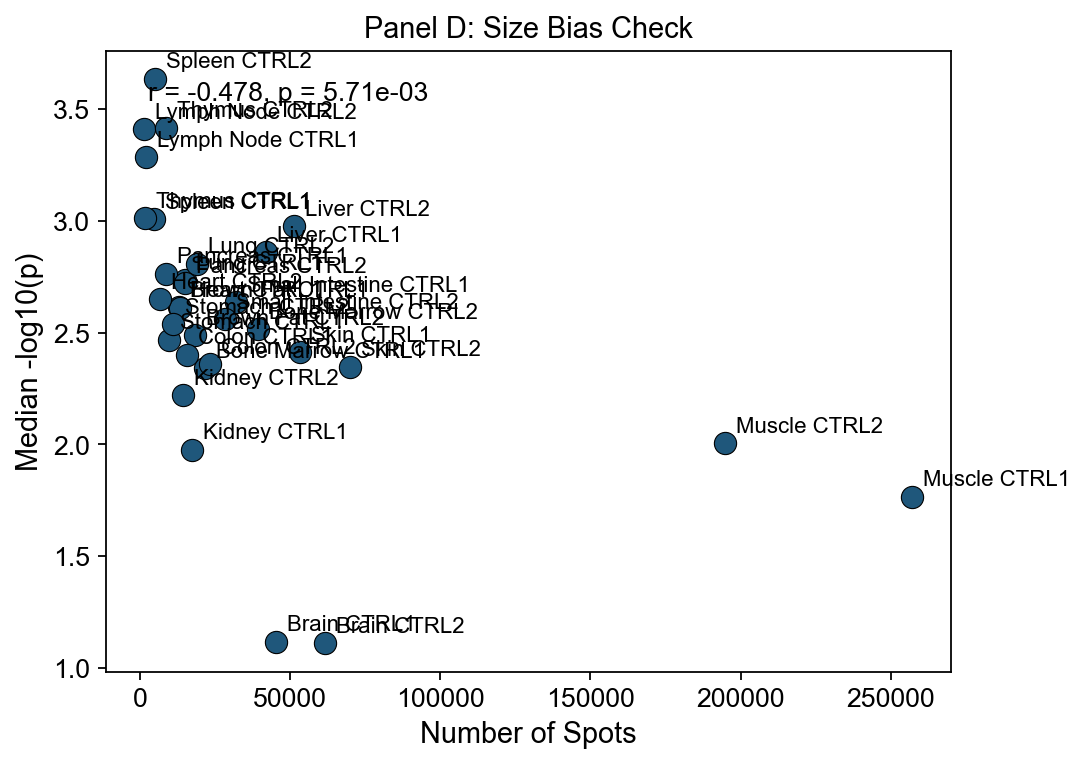

In [7]:
size_bias = spot_all.groupby('sample_name').agg(
    n_spots=('p', 'count'),
    median_logp=('p', lambda x: np.median(-np.log10(x.dropna())))
).reset_index()
size_bias['organ'] = size_bias['sample_name'].apply(lambda x: x.rsplit('_', 1)[0].replace('_', ' '))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(size_bias['n_spots'], size_bias['median_logp'], s=100, edgecolors='k', linewidths=0.5, zorder=3)
for _, row in size_bias.iterrows():
    ax.annotate(row['sample_name'].replace('_', ' '), (row['n_spots'], row['median_logp']),
               fontsize=LEGEND_FS - 1, xytext=(5, 5), textcoords='offset points')

if len(size_bias) >= 3:
    r, pval = pearsonr(size_bias['n_spots'], size_bias['median_logp'])
    ax.text(0.05, 0.95, f'r = {r:.3f}, p = {pval:.2e}', transform=ax.transAxes,
            fontsize=TEXT_FS, va='top')

ax.set_xlabel('Number of Spots', fontsize=LABEL_FS)
ax.set_ylabel('Median -log10(p)', fontsize=LABEL_FS)
ax.set_title('Panel D: Size Bias Check', fontsize=TITLE_FS)
ax.tick_params(labelsize=TICK_FS)
fig.tight_layout()
save_all_formats(fig, f'{BASE}/figures/S02D_size_bias')